---
title: QQ Plots
subtitle: DS 2023 | Communicating with Data
---

<img src="https://virginia.box.com/shared/static/ii1gex9nbwt6hcyrwqx25g2wu4t5cmke.png" style="width:500px;">

## Overview

In the same way that a histogram is a special case of a bar chart, a Q-Q plot is a **special case of a scatter plot**.

It plots two numeric statistical features on the x and y axes, usually **the quantiles of two probability distributions**, $Q_1$ and $Q_2$.

Hence the name "Q–Q" &mdash; short for quantile–quantile.

Q-Q plots also typically add a diagonal line plot to the figure as a reference, where $y = x$.

If the sample follows the model, the points will fall along the line.

Systematic departures reveal how the two distributions differ.

$Q_1$ and $Q_2$ are often a **model** and **sample**, respectively, but sometimes they are **two samples**.


## Use Cases

Like histograms, Q-Q plots allow the user to quickly see the statistical properties of a distribution, such as skew, tails, and outliers. 

However, Q-Q plots are optimized to **show how a distribution differs from a model**, such as the normal distribution.

Q-Q plots can also be used to **compare two samples to see if they come from the same population**.

In either case, the more similar $Q_1$ and $Q_2$ are, they more their points will align with the identity line, i.e. the line produced by the function $x = y$.

## Creating a Q-Q plot from scratch

The essential part of creating a Q-Q plot is preparing the data, then displaying them with a scatter plot and a reference line.

When comparing a variables's distribution against a theoretical model, the general data preparation
steps are:

**Rank the variable data.**

- Choose a numeric measurement variable, aka the sample, and sort its values in ascending order.
- Assign each value a rank $r$, starting at $1$ for the smallest value and ending at $N$ for the largest.
- These sorted values are the sample quantiles, $Q_2$.

**Scale the rank values.**

- For each rank, apply the formula to get the **cumulative probability**.

  $$p_r = \frac{r - 0.5}{N}$$

  where $r$ is the rank of the data point and $N$ is the total number of observations.
- This effectively scales the data to values between $.05$ and $.95$.
- The result is an evenly spaced set probabilities.
- The values tell you the percentile is associated with the variable value.

> [!NOTE] The formula used here is known as Hazen's formula. Others exist, such as Blom's.
>
> To learn more about these, check out the excellent guide to Q-Q plots offered by [Statistics Fundamentals](https://statisticsfundamentals.com/data-visualization/qq-plots/).


**Convert the scaled ranks into theoretical quantiles.**

- Choose a theoretical distribution.
  - This is the model you want to compare your sample data against.
  - This is often the standard normal distribution.
- Pass each $p_r$ to the model's *inverse* cumulative distribution function (CDF).
- This is **the quantile function**.
- For the standard normal distribution this is $\Phi^{-1}$ (`norm.ppf`), which maps the evenly spaced probabilities to values that are bunched near the center and spread out in the tails.
- The results are the theoretical quantiles, $Q_1$.

**Plot the resulting data.**

- Draw a scatter plot of $Q_1$ (the model) on the x-axis and $Q_2$ (the sample) on the y-axis.
- Overlay a reference line:
  - If you standardized the sample first, $z = (x - \bar{x})/s$, use $y = x$.
  - Otherwise use $y = \bar{x} + s\,x$, or a line through the first and third quartiles of the points.
- Points close to the line indicate a good fit; curves, S-shapes, or bent tails reveal how the sample's distribution departs from the model.
- Only the *straightness* matters for judging shape: if the data are normal with mean $\mu$ and standard deviation $\sigma$, the points fall near the line $y = \mu + \sigma x$, so the mean and spread change only the line's intercept and slope.

Here is an example using NumPy, Pandas, and Matplotlib.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We start by taking a random sample of $100$ observations from the normal distribution.

In [3]:
my_sample = np.random.normal(0, 1, 1000)
my_sample[:5]

array([-1.62243963,  0.30425743,  0.70458653, -0.61439451,  0.57320535])

We then create a data frame to store the features for our Q-Q plot.

In [4]:
QQ = pd.DataFrame({
    'q2':my_sample
})
QQ['rank'] = QQ.q2.rank(method='first')
QQ.sort_values('rank')

,q2,rank
158,-2.986523,1.0
292,-2.726317,2.0
661,-2.666008,3.0
907,-2.500953,4.0
232,-2.446987,5.0
...,...,...
23,2.743125,996.0
21,2.836360,997.0
983,2.857956,998.0
925,2.877345,999.0


Next, we compute the plotting positions, which are just probabilities.

In [5]:
QQ['p'] = (QQ['rank'] - .5) / len(QQ)
QQ.head()

,q2,rank,p
0,-1.622440,56.0,0.0555
1,0.304257,635.0,0.6345
2,0.704587,774.0,0.7735
3,-0.614395,296.0,0.2955
4,0.573205,734.0,0.7335


Note the `p` just tells you the percent of observations below it.

In [6]:
(len(QQ[QQ.p <= .5765]) / len(QQ)) * 100

57.699999999999996

Finally, we convert the plotting positions into theoretical quantiles. 

Here, we fall back on the SciPy's [`scipy.stats.norm()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) function to do the heavy lifting.

In [7]:
import scipy.stats as stats
QQ['q1'] = stats.norm.ppf(QQ['p'])
QQ.head()

,q2,rank,p,q1
0,-1.622440,56.0,0.0555,-1.593714
1,0.304257,635.0,0.6345,0.343796
2,0.704587,774.0,0.7735,0.750423
3,-0.614395,296.0,0.2955,-0.537387
4,0.573205,734.0,0.7335,0.623433


Now, we just create a scatter plot with a reference line.

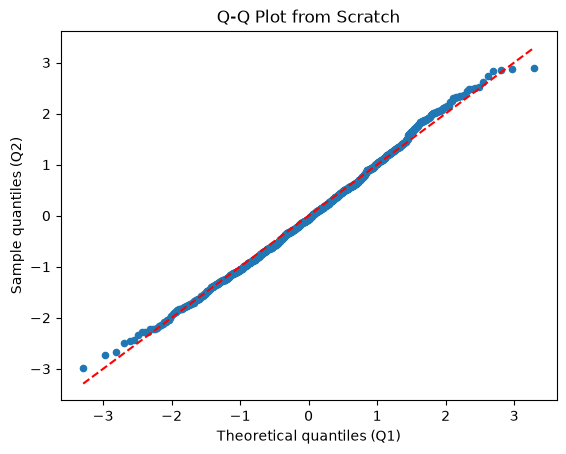

In [8]:
ax = QQ.plot.scatter('q1', 'q2')   # theoretical on x, sample on y
lims = [QQ.q1.min(), QQ.q1.max()]
ax.plot(lims, lims, ls='--', c='red')
ax.set_xlabel("Theoretical quantiles (Q1)")
ax.set_ylabel("Sample quantiles (Q2)")
ax.set_title("Q-Q Plot from Scratch")
plt.show()

Here is a minimalist version of a function to create a q-q plot.

In [9]:
def qqplot(S):
    q2 = sorted(S)                                   # sample quantiles
    p = [(i + 1 - .5) / len(S) for i in range(len(S))]
    q1 = stats.norm.ppf(p)                           # theoretical quantiles
    fig, ax = plt.subplots()
    ax.plot(q1, q2, 'o')
    limits = [min(q1), max(q1)]
    ax.plot(limits, limits, c='red', ls='-')

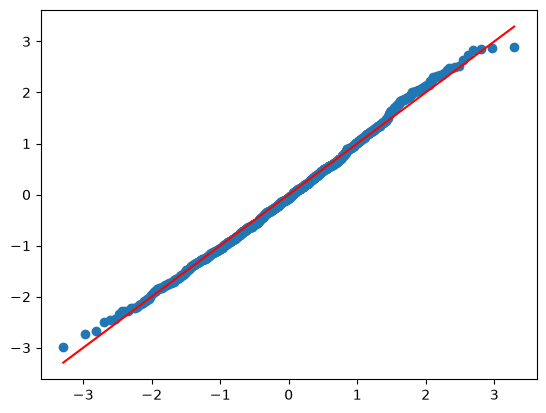

In [10]:
qqplot(my_sample)

## Using SciPy and Statsmdolels

Python's two main statistical libraries, SciPy and Statsmodels, each have functions that will produce a Q-Q plot in Matplotlib for you.

Here is SciPy's [`.stats.probplot()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html) function.

Here we see it with the `plot` argument set, which automatically produces a plot for us.

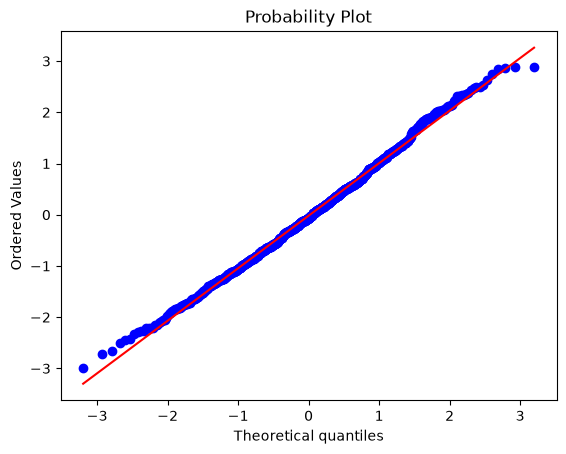

In [11]:
stats.probplot(QQ.q2, dist="norm", plot=plt)
plt.show()

And here is [the Statsmodels version](https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html), which by default produces a plot.

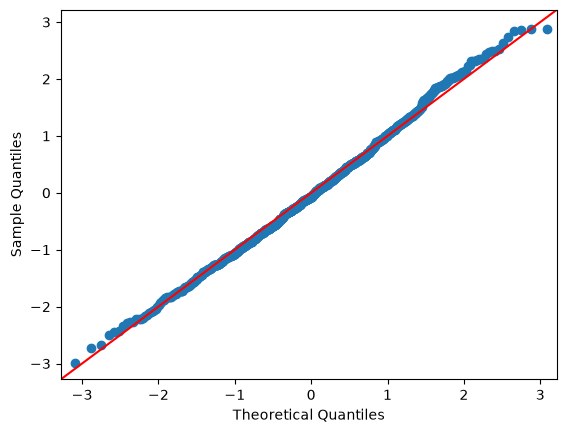

In [12]:
import statsmodels.api as sm

sm.qqplot(QQ.q2, line ='45')
plt.show()

In both cases, the resulting plot is a Matplotlib object that can be further manipulated using PyPlot (`plt`).

> [!NOTE] There are some differences between the two libraries' plots.
>
> They differ in how the reference line is constructed and how the axes are labeled.
>
> Do you notice others?

## Using Pingouin

One issue with the two QQ plot functions described above is that neither returns a Matplotlib Axes object.

This means that it is hard to combine them with other plots and otherwise amend them.

Pingouin, another statistical package in the Python world, does return an Axes object.

It also presents a well annotated plot.

In [13]:
import pingouin as pg

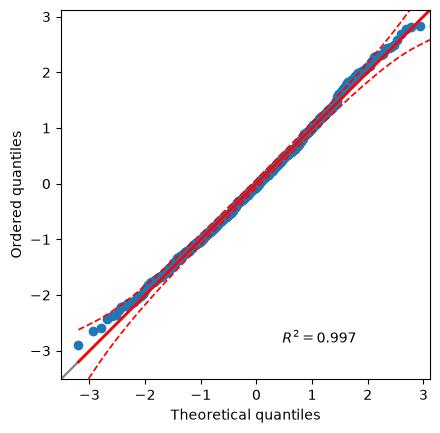

In [14]:
ax = pg.qqplot(QQ.q2, dist='norm', color='tab:blue')

## Using Seaborn

Seaborn supports Q-Q plots with the `pplot` function, which comes with the [seaborn-qqplot extension](https://seaborn-qqplot.readthedocs.io/en/latest/#). 

It's pretty bare bones, though, so you have to include the diagonal and anything else by hand.

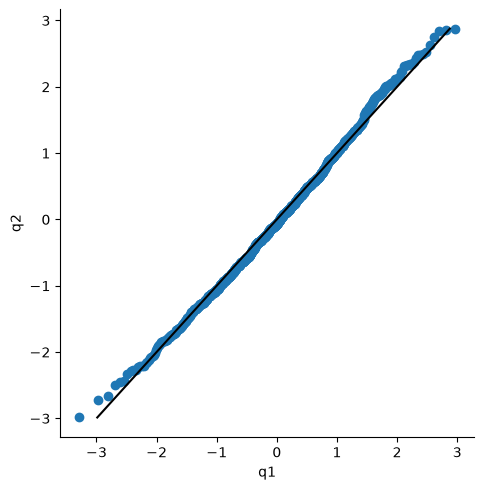

In [51]:
from seaborn_qqplot import pplot

pplot(QQ, x="q1", y="q2", kind='qq', height=5, display_kws={"identity":True})
# plt.plot([-3,3], [-3,3], c='red', ls='--', lw=2)
plt.show()

What is nice about `pplot` is that it is very general, exposing both the x and y axes to any series of data.

So, for example, we can easily compare the distributions of two measurement variables like so:

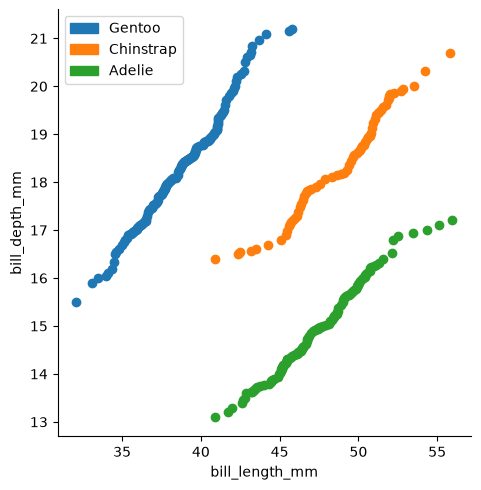

In [58]:
penguins = sns.load_dataset('penguins')

pplot(penguins, x='bill_length_mm', y='bill_depth_mm', kind='qq', hue='species', height=5)
plt.show()

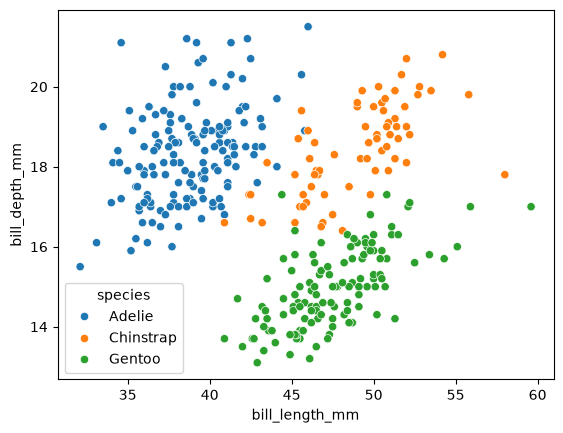

In [56]:
penguins = sns.load_dataset('penguins')

sns.scatterplot(penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.show()

## Comparison to histrograms and density plots

Let's look at an example to illustrate how Q-Q plots compare to histograms and density plots for investigating the properties of a distribution.

We use the same data set we used when looking at histograms.

In [38]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


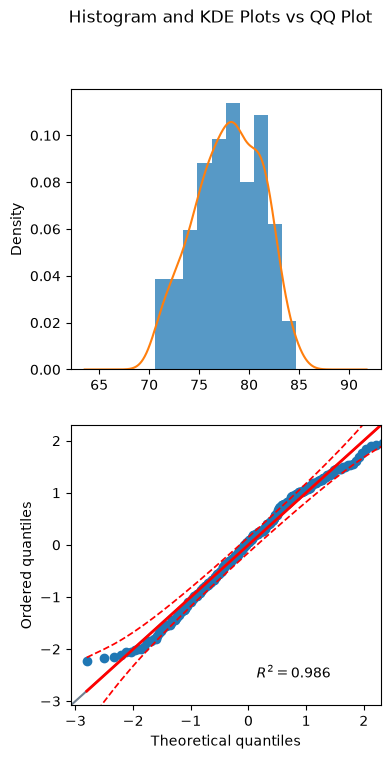

In [39]:
fig, ax = plt.subplots(2, 1, figsize=(4, 8))

S = healthexp.Life_Expectancy

S.plot.hist(density=True, alpha=.75, ax=ax[0])
S.plot.kde(ax=ax[0])

pg.qqplot(S, dist='norm', square=False, color='tab:blue', ax=ax[1])

plt.suptitle("Histogram and KDE Plots vs QQ Plot")

plt.show()

Looking at the Q-Q plot, we can see two things right away.

First, there is a good **overall fit** through the center of the distribution.

- Roughly the middle two-thirds, between theoretical quantiles of about $−1.5$ and $+1.5$.
- This means that a normal model describes the bulk of this data well.
- It is reasonably symmetric with no strong skew, and the central shape is essentially Gaussian.

Second, the curves at either end of the plot reveal something about **the tails** of the distribution. 

- The points lie *above* the line on the left and *below* it on the right.
- This indicates that the most extreme observed values are *less* extreme than a normal distribution would predict.
- Statisticians would say the distribution has **short, light tails**. 

In both cases, **the Q-Q plot is more informative** than the other two. 

- It immediately directs your attention these facts.
- In contrast, a histogram's look is sensitive to the number of **bins** selected.
- And the KDE's is sensitive to **bandwidth**, which can smooth away or even invent features. 

Visually, the two on the left spend almost all their visual space (data ink) on the dense center.

- They squash the sparse tails into near-zero slivers
- This make deviations from normality are almost impossible to see. 

So, while the histogram and KDE are better for conveying overall shape, modality, and the actual data scale to a general audience, the Q-Q plot is the better diagnostic for judging *how* and *where* the distribution departs from a chosen model — especially in the tails, which is exactly where it matters most.

## A final example

In our final example, we use the `tips` dataset to show how a sample can diverge from the model.

First, let's define a simple function to plot four panels showing a histogram and density plot above the QQ plot for a given series.

In [59]:
def myqq(S):
    fig, ax = plt.subplots(2, figsize=(5, 8))

    S.plot.hist(density=True, alpha=.75, ax=ax[0])
    S.plot.kde(ax=ax[0])
    pg.qqplot(S, dist='norm', square=False, ax=ax[1])
        
    plt.tight_layout()
    plt.show()

In [60]:
tips = sns.load_dataset('tips')

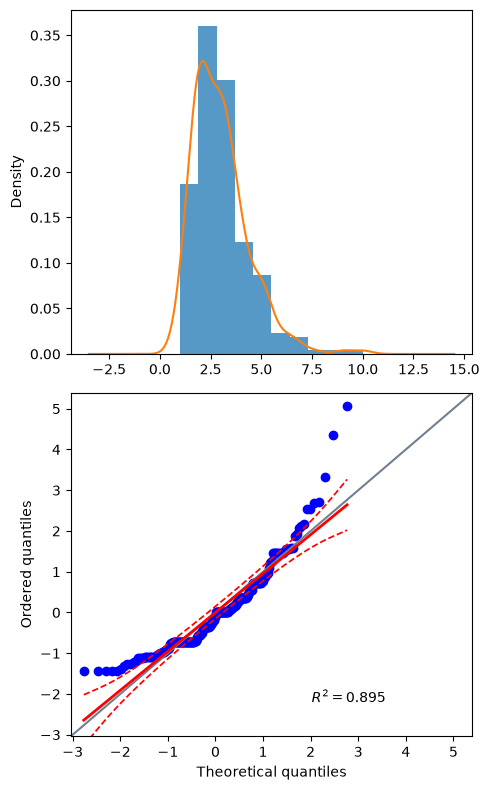

In [61]:
myqq(tips.tip)

Overall, we can see that the plot is right-skewed. It's normal in the middle, squeezed as the bottom and stretched at the top.

The **left tail:** is sqeezed, flattening above the line at about $-1.45$.

This is because the $\$1.00$ minimum tip acts as a floor.

The **right tail:** is stretched, bending up and away.

This is because the largest tips sit $3$ to $5$ standard deviations above the mean ($\$10$ max).

Here is a similar pattern:

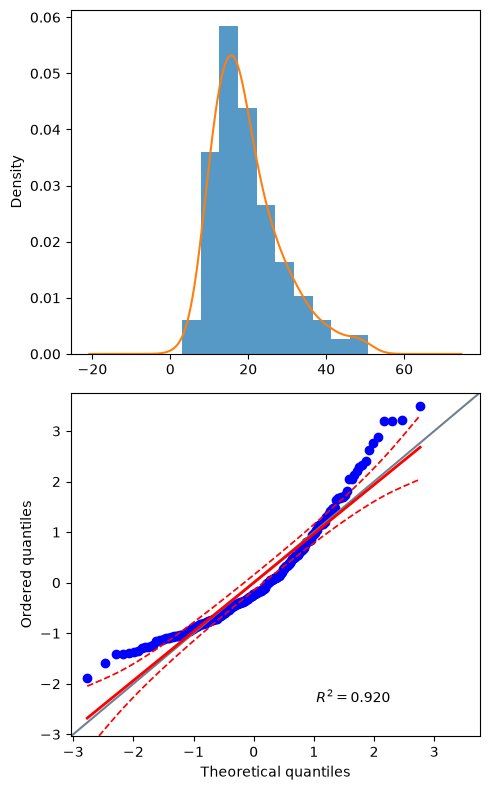

In [62]:
myqq(tips.total_bill)

You can see that the plot does not work well with discrete values from a small domain.

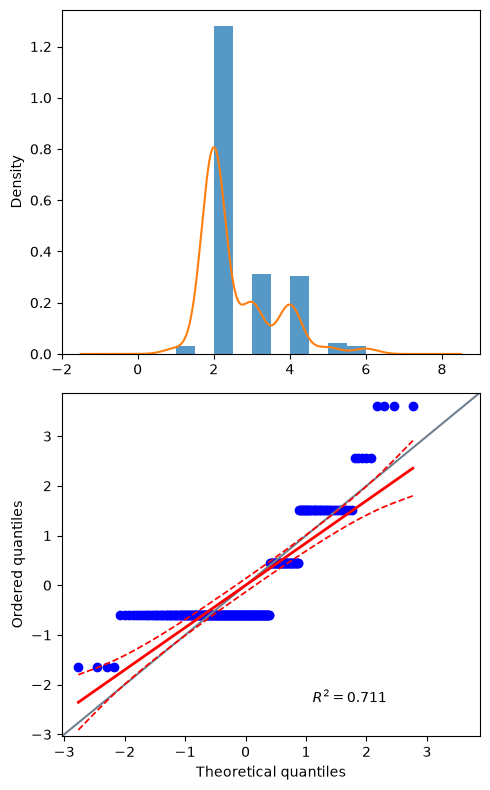

In [63]:
myqq(tips['size'])

In [64]:
tips['size'].value_counts()

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64